# **Bioinformatics Project - Computational Drug Discovery [Part 2] Exploratory Data Analysis**

Chanin Nantasenamat

[*'Data Professor' YouTube channel*](http://youtube.com/dataprofessor)

In this Jupyter notebook, we will be building a real-life **data science project** that you can include in your **data science portfolio**. Particularly, we will be building a machine learning model using the ChEMBL bioactivity data.

In **Part 2**, we will be performing Descriptor Calculation and Exploratory Data Analysis.

---

## **Install conda and rdkit**

In [1]:
! wget https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
! bash Miniconda3-latest-Linux-x86_64.sh -b -f -p /usr/local
! source ~/.bashrc
#! pip install rdkit
#! conda install -c rdkit rdkit -y


--2026-10-08 09:43:08--  https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
Resolving repo.anaconda.com (repo.anaconda.com)... 104.16.191.158, 104.16.32.241, 2606:4700::6810:20f1, ...
Connecting to repo.anaconda.com (repo.anaconda.com)|104.16.191.158|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 197973354 (189M) [application/octet-stream]
Saving to: ‘Miniconda3-latest-Linux-x86_64.sh’

Miniconda3-latest-L 100%[===================>] 188.80M   234MB/s    in 0.8s    

2026-10-08 09:43:09 (234 MB/s) - ‘Miniconda3-latest-Linux-x86_64.sh’ saved [197973354/197973354]

PREFIX=/usr/local
Unpacking bootstrapper...
Unpacking payload...

Installing base environment...

Preparing transaction: ...working... done
Executing transaction: ...working... done
installation finished.
    You currently have a PYTHONPATH environment variable set. This may cause
    unexpected behavior when running the Python interpreter in Miniconda3.
    For best results, please

In [ ]:
# not needed...it is just to check the installation
import sys

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Python paths:")
for p in sys.path:
    print("  ", p)

Python executable: /usr/bin/python3
Python version: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
Python paths:
   /content
   /env/python
   /usr/lib/python313.zip
   /usr/lib/python3.13
   /usr/lib/python3.13/lib-dynload
   
   /usr/local/lib/python3.13/dist-packages
   /usr/lib/python3/dist-packages
   /usr/local/lib/python3.13/dist-packages/IPython/extensions
   /root/.ipython


In [2]:
import sys
!{sys.executable} -m pip install rdkit
#sys.path.append('/usr/local/lib/python3.14/site-packages/rdkit')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 21.3 MB/s eta 0:00:00


## **Load bioactivity data**

In [3]:
import pandas as pd
df = pd.read_csv('bioactivity_preprocessed_data_exp1.csv')

## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

### **Import libraries**

In [4]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [5]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [6]:
# prints are not needed. USe them to learn more about how SMILES and Lipinski look like
# print(df.canonical_smiles.head(3))
df_lipinski = lipinski(df.canonical_smiles)
# print('-------- Lipinski:\n',df_lipinski.head(3))

-------- Lipinski:
         MW     LogP  NumHDonors  NumHAcceptors
0  281.271  1.89262         0.0            5.0
1  415.589  3.81320         0.0            2.0
2  421.190  2.66050         0.0            4.0


### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [ ]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,281.271,1.89262,0.0,5.0
1,415.589,3.81320,0.0,2.0
2,421.190,2.66050,0.0,4.0
3,293.347,3.63080,0.0,3.0
4,338.344,3.53900,0.0,5.0
...,...,...,...,...
257,465.594,2.19130,2.0,4.0
258,499.534,1.09718,3.0,5.0
259,452.555,2.44660,4.0,4.0
260,464.497,1.85800,4.0,4.0


In [ ]:
df

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,intermediate,7200.0
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,intermediate,9400.0
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,13500.0
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,13110.0
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],intermediate,2000.0
...,...,...,...,...
257,CHEMBL5565858,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,48.0
258,CHEMBL4802135,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@H]2[C@...,active,20.0
259,CHEMBL4796938,O=C[C@H](C[C@@H]1CCNC1=O)NC(=O)[C@H](CC1CCCCC1...,active,53.0
260,CHEMBL4764751,O=C[C@H](C[C@@H]1CCNC1=O)NC(=O)[C@H](Cc1cccc(F...,active,40.0


Now, let's combine the 2 DataFrame

In [7]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [8]:
df_combined

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,intermediate,7200.0,281.271,1.89262,0.0,5.0
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,intermediate,9400.0,415.589,3.81320,0.0,2.0
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,13500.0,421.190,2.66050,0.0,4.0
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,13110.0,293.347,3.63080,0.0,3.0
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],intermediate,2000.0,338.344,3.53900,0.0,5.0
...,...,...,...,...,...,...,...,...
239,CHEMBL5565858,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,48.0,465.594,2.19130,2.0,4.0
240,CHEMBL4802135,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@H]2[C@...,active,20.0,499.534,1.09718,3.0,5.0
241,CHEMBL4796938,O=C[C@H](C[C@@H]1CCNC1=O)NC(=O)[C@H](CC1CCCCC1...,active,53.0,452.555,2.44660,4.0,4.0
242,CHEMBL4764751,O=C[C@H](C[C@@H]1CCNC1=O)NC(=O)[C@H](Cc1cccc(F...,active,40.0,464.497,1.85800,4.0,4.0


- **Check units first.** ChEMBL has standard_units (usually nM, but not always). Convert everything to nM before the formula, or you'll get wrong values.
- **Exclude zero or negative IC50**. log10(0) is undefined, so drop those rows.
- **Censored values** like >10000 nM aren't exact. Keep only standard_relation == "=" for regression, or use them as "inactive" labels for classification.
- IC50 depends on assay conditions (enzyme and substrate concentration), so values from different papers aren't perfectly comparable. **Ki and Kd** are more intrinsic measures, but far fewer compounds have them, and the same -log10 conversion gives pKi and pKd.




### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [39]:
# https://github.com/chaninlab/estrogen-receptor-alpha-qsar/blob/master/02_ER_alpha_RO5.ipynb

import numpy as np

def pIC50(input, fieldName = 'standard_value'):
    # Convert IC50 to pIC50
    pIC50 = []

    for i in input[fieldName]:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop(fieldName, axis=1)

    return x

**Point to note**: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

`-np.log10( (10**-9)* 10**10 ) = -1`

**Why capping is risky**

The cap would be extremely high potency if it's a floor, or an impossible number if it's a ceiling:

- If you replace 0 with 10⁻⁸ nM, pIC50 becomes 17, a fantasy potency that would be an extreme outlier and pull the model toward it.
- If you cap at 10⁸ nM (0.1 M), that's far beyond any real assay range (eg.they won't dissolve at that concentration), so it would do nothing useful.
- Every capped row gets exactly the same pIC50 (1.0). The distribution then has an artificial pile-up at one value

In [10]:
df_combined.standard_value.describe()

,standard_value
count,244.000000
mean,50132.564877
std,108808.011836
min,14.000000
25%,3014.962500
50%,12785.000000
75%,40000.000000
max,1000000.000000


In [40]:
# remove zero/negative values (as explained above)

df_norm = df_combined[df_combined["standard_value"] <= 10**8]
fieldName = 'standard_value'

print("Removed:", len(df_combined) - len(df_norm))

Removed: 0


In [ ]:
# this function is used if you want to cap them
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [37]:
# this invokation is used if you want to cap them (alternative to drop)
# df_norm = norm_value(df_combined)
df_norm
fieldName = 'standard_value_norm'

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,intermediate,7200.0,281.271,1.89262,0.0,5.0
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,intermediate,9400.0,415.589,3.81320,0.0,2.0
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,13500.0,421.190,2.66050,0.0,4.0
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,13110.0,293.347,3.63080,0.0,3.0
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],intermediate,2000.0,338.344,3.53900,0.0,5.0
...,...,...,...,...,...,...,...,...
239,CHEMBL5565858,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,48.0,465.594,2.19130,2.0,4.0
240,CHEMBL4802135,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@H]2[C@...,active,20.0,499.534,1.09718,3.0,5.0
241,CHEMBL4796938,O=C[C@H](C[C@@H]1CCNC1=O)NC(=O)[C@H](CC1CCCCC1...,active,53.0,452.555,2.44660,4.0,4.0
242,CHEMBL4764751,O=C[C@H](C[C@@H]1CCNC1=O)NC(=O)[C@H](Cc1cccc(F...,active,40.0,464.497,1.85800,4.0,4.0


In [ ]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,2.620000e+02
mean,6.451621e+04
std,1.798523e+05
min,1.400000e+01
25%,3.325000e+03
50%,1.340000e+04
75%,4.450000e+04
max,2.000000e+06


In [41]:
df_final = pIC50(df_norm, fieldName)
df_final

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,intermediate,281.271,1.89262,0.0,5.0,5.142668
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,intermediate,415.589,3.81320,0.0,2.0,5.026872
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,421.190,2.66050,0.0,4.0,4.869666
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,293.347,3.63080,0.0,3.0,4.882397
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],intermediate,338.344,3.53900,0.0,5.0,5.698970
...,...,...,...,...,...,...,...,...
239,CHEMBL5565858,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,465.594,2.19130,2.0,4.0,7.318759
240,CHEMBL4802135,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@H]2[C@...,active,499.534,1.09718,3.0,5.0,7.698970
241,CHEMBL4796938,O=C[C@H](C[C@@H]1CCNC1=O)NC(=O)[C@H](CC1CCCCC1...,active,452.555,2.44660,4.0,4.0,7.275724
242,CHEMBL4764751,O=C[C@H](C[C@@H]1CCNC1=O)NC(=O)[C@H](Cc1cccc(F...,active,464.497,1.85800,4.0,4.0,7.397940


In [42]:
df_final.pIC50.describe()

,pIC50
count,244.000000
mean,5.072448
std,1.020146
min,3.000000
25%,4.397940
50%,4.893361
75%,5.520720
max,7.853872


### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [43]:
df_final[df_final.bioactivity_class == 'intermediate']

,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL187579,Cc1noc(C)c1CN1C(=O)C(=O)c2cc(C#N)ccc21,intermediate,281.271,1.89262,0.0,5.0,5.142668
1,CHEMBL188487,O=C1C(=O)N(Cc2ccc(F)cc2Cl)c2ccc(I)cc21,intermediate,415.589,3.81320,0.0,2.0,5.026872
4,CHEMBL187717,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c1cccc2[N+](=O)[O-],intermediate,338.344,3.53900,0.0,5.0,5.698970
6,CHEMBL187598,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccc(F)cc21,intermediate,311.337,3.76990,0.0,3.0,5.316953
20,CHEMBL383725,O=C1C(=O)N(Cc2ccc3ccccc3c2)c2ccc(I)cc21,intermediate,413.214,4.17390,0.0,2.0,5.958607
22,CHEMBL208732,O=C(CSc1nccc(-c2csc(-c3ccccc3)n2)n1)Nc1cc(Cl)c...,intermediate,473.410,6.30470,1.0,6.0,5.520000
23,CHEMBL208732,O=C(CSc1nccc(-c2csc(-c3ccccc3)n2)n1)Nc1cc(Cl)c...,intermediate,473.410,6.30470,1.0,6.0,5.522879
77,CHEMBL213581,Nc1ncc(S(=O)(=O)c2ccc(Cl)cc2)c(N)n1,intermediate,284.728,1.12720,2.0,6.0,5.221849
87,CHEMBL379642,O=C(Sc1nnc(C(F)(F)F)[nH]1)c1ccc(C#Cc2ccccc2)o1,intermediate,363.320,3.74880,1.0,5.0,5.522879
88,CHEMBL427404,Cc1noc(NC(=O)c2ccc(-c3cc(C(F)(F)F)nn3C)s2)c1[N...,intermediate,401.326,3.62432,1.0,7.0,5.301030


In [46]:
df_2class = df_final[df_final.bioactivity_class != 'intermediate']
print('Dropped:', len(df_final) - len(df_2class))
df_2class


Dropped: 50


,molecule_chembl_id,canonical_smiles,bioactivity_class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
2,CHEMBL185698,O=C1C(=O)N(CC2COc3ccccc3O2)c2ccc(I)cc21,inactive,421.190,2.66050,0.0,4.0,4.869666
3,CHEMBL426082,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccccc21,inactive,293.347,3.63080,0.0,3.0,4.882397
5,CHEMBL365134,O=C1C(=O)N(Cc2cc3ccccc3s2)c2c(Br)cccc21,active,372.243,4.39330,0.0,3.0,6.008774
7,CHEMBL190743,O=C1C(=O)N(Cc2cc3ccccc3s2)c2ccc(I)cc21,active,419.243,4.23540,0.0,3.0,6.022276
8,CHEMBL365469,O=C1C(=O)N(Cc2cc3ccccc3s2)c2cccc(Cl)c21,inactive,327.792,4.28420,0.0,3.0,4.950782
...,...,...,...,...,...,...,...,...
239,CHEMBL5565858,CC1(C)[C@@H]2[C@@H](C(=O)N[C@H](C=O)C[C@@H]3CC...,active,465.594,2.19130,2.0,4.0,7.318759
240,CHEMBL4802135,CC(C)(C)[C@H](NC(=O)C(F)(F)F)C(=O)N1C[C@H]2[C@...,active,499.534,1.09718,3.0,5.0,7.698970
241,CHEMBL4796938,O=C[C@H](C[C@@H]1CCNC1=O)NC(=O)[C@H](CC1CCCCC1...,active,452.555,2.44660,4.0,4.0,7.275724
242,CHEMBL4764751,O=C[C@H](C[C@@H]1CCNC1=O)NC(=O)[C@H](Cc1cccc(F...,active,464.497,1.85800,4.0,4.0,7.397940


---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [48]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

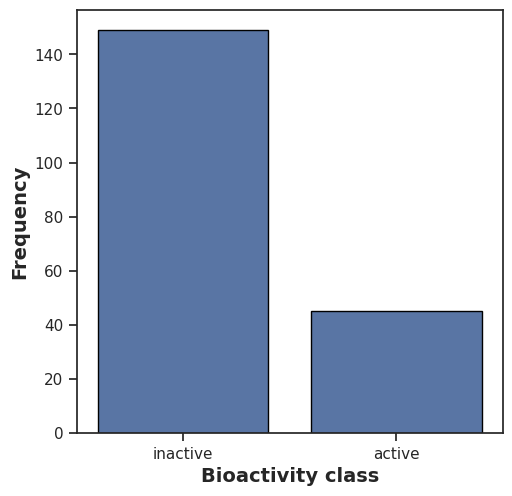

In [49]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

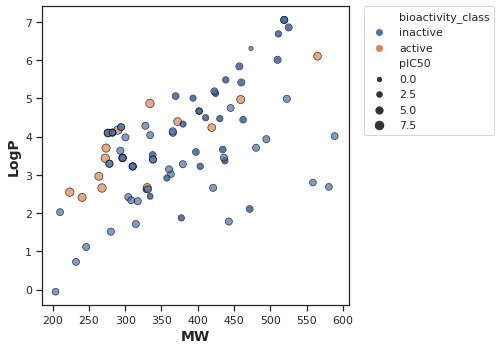

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

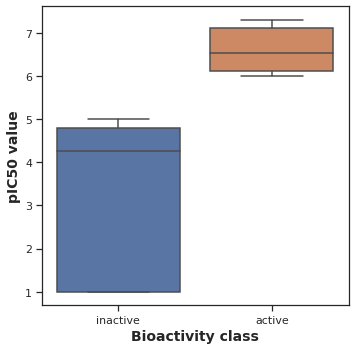

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [ ]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,0.0,1.662636e-10,0.05,Different distribution (reject H0)


#### **MW**

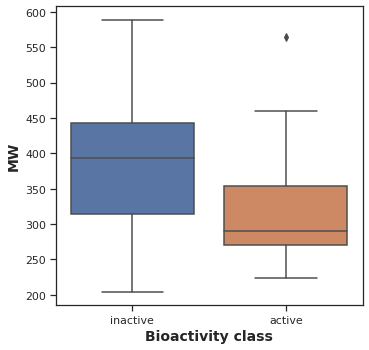

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [ ]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,409.5,0.001525,0.05,Different distribution (reject H0)


#### **LogP**

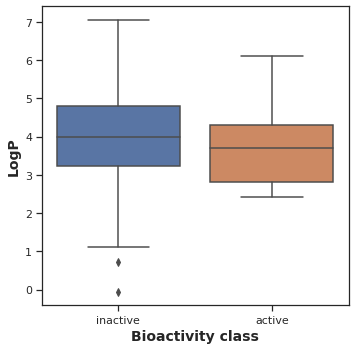

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,712.5,0.295805,0.05,Same distribution (fail to reject H0)


#### **NumHDonors**

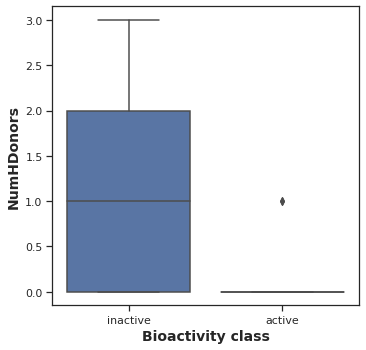

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,299.5,0.000024,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

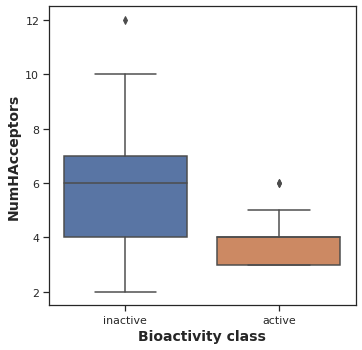

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [ ]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,415.0,0.001557,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

Of the 4 Lipinski's descriptors (MW, LogP, NumHDonors and NumHAcceptors), only LogP exhibited ***no difference*** between the **actives** and **inactives** while the other 3 descriptors (MW, NumHDonors and NumHAcceptors) shows ***statistically significant difference*** between **actives** and **inactives**.

## **Zip files**

In [ ]:
! zip -r results.zip . -i *.csv *.pdf

  adding: mannwhitneyu_NumHAcceptors.csv (deflated 12%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 9%)
  adding: plot_LogP.pdf (deflated 37%)
  adding: mannwhitneyu_LogP.csv (deflated 7%)
  adding: plot_MW_vs_LogP.pdf (deflated 15%)
  adding: plot_ic50.pdf (deflated 37%)
  adding: plot_NumHDonors.pdf (deflated 38%)
  adding: plot_NumHAcceptors.pdf (deflated 37%)
  adding: plot_MW.pdf (deflated 38%)
  adding: mannwhitneyu_pIC50.csv (deflated 10%)
  adding: bioactivity_data_preprocessed.csv (deflated 80%)
  adding: plot_bioactivity_class.pdf (deflated 38%)
  adding: mannwhitneyu_MW.csv (deflated 9%)
